## Imports & Configurations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

star_colors = np.load(os.path.join(os.getcwd(), '..', 'Outputs', 'star_colors.npz'))
r_i_clean_star = star_colors['r_i_clean_star']
g_r_clean_star = star_colors['g_r_clean_star']
u_g_clean_star = star_colors['u_g_clean_star']
i_z_clean_star = star_colors['i_z_clean_star']

qso_colors = np.load(os.path.join(os.getcwd(), '..', 'Outputs', 'quasar_colors.npz'))
r_i_clean_qso = qso_colors['r_i_clean_qso']
g_r_clean_qso = qso_colors['g_r_clean_qso']
u_g_clean_qso = qso_colors['u_g_clean_qso']
i_z_clean_qso = qso_colors['i_z_clean_qso']
Z = qso_colors['Z']

## Optical Color-Color Diagrams of Stars

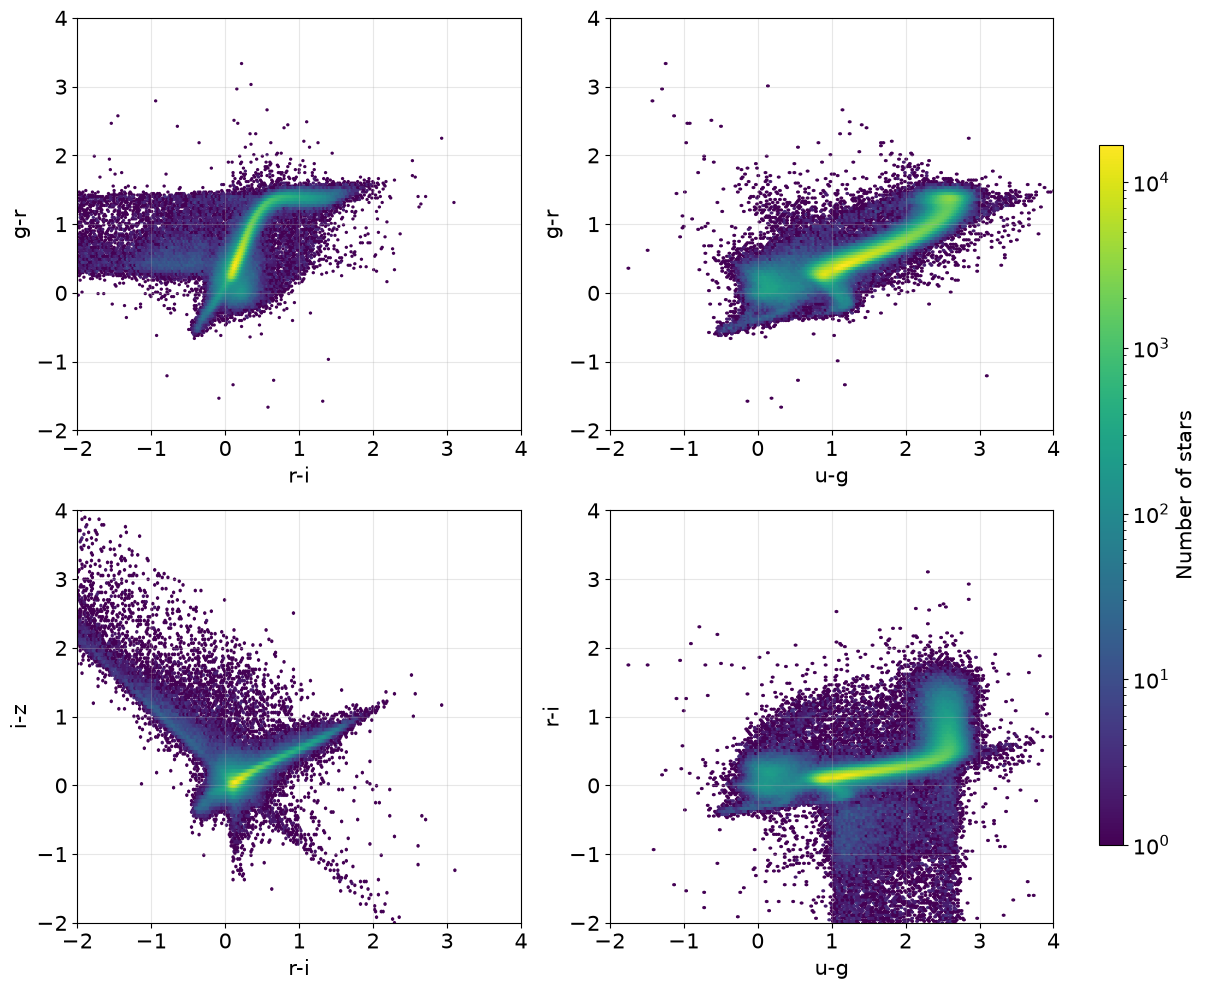

In [2]:
stars_color_pairs = [
    (r_i_clean_star, g_r_clean_star, 'r-i', 'g-r'),
    (u_g_clean_star, g_r_clean_star, 'u-g', 'g-r'),
    (r_i_clean_star, i_z_clean_star, 'r-i', 'i-z'),
    (u_g_clean_star, r_i_clean_star, 'u-g', 'r-i')
]

fig, axes = plt.subplots(2,2,figsize=(12,10),sharex=False,sharey=False)

axes = axes.flatten()

for ax, (x, y, xlabel, ylabel) in zip(axes, stars_color_pairs):
    hb = ax.hexbin(x,y,cmap='viridis',gridsize=200,mincnt=1,norm=LogNorm())
    ax.set_xlim(-2,4)
    ax.set_ylim(-2,4)
    ax.set_xlabel(xlabel,fontsize=15)
    ax.set_ylabel(ylabel,fontsize=15)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=15)
cbar_ax=fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(hb,cax=cbar_ax,label='Number of stars')
cbar_ax.yaxis.label.set_size(15)
cbar_ax.tick_params(labelsize=15)
#fig.suptitle('Optical Color-Color Diagrams of Stars',fontsize=15)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

## Color-Color Diagrams of Stars and Quasars

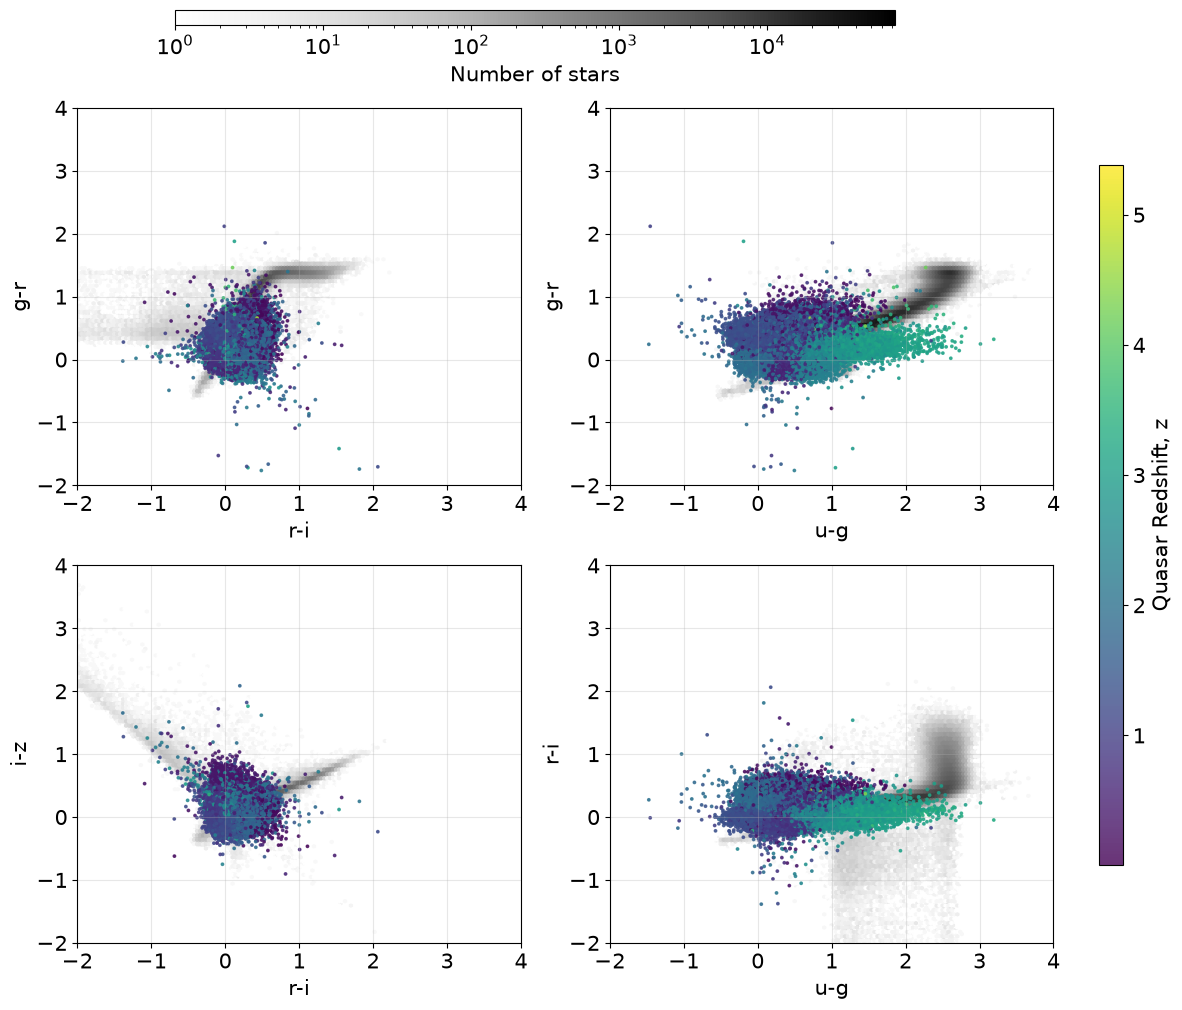

In [3]:
color_pairs = [
    (r_i_clean_star, g_r_clean_star, r_i_clean_qso, g_r_clean_qso, 'r-i', 'g-r'),
    (u_g_clean_star, g_r_clean_star, u_g_clean_qso, g_r_clean_qso, 'u-g', 'g-r'),
    (r_i_clean_star, i_z_clean_star, r_i_clean_qso, i_z_clean_qso, 'r-i', 'i-z'),
    (u_g_clean_star, r_i_clean_star, u_g_clean_qso, r_i_clean_qso, 'u-g', 'r-i'),
]

fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.flatten()

star_hexbins = []

for ax,(sx,sy,qx,qy,xlab,ylab) in zip(axes,color_pairs):

    hb = ax.hexbin(sx, sy, gridsize=150, cmap='Greys', mincnt=1, norm=LogNorm(),extent=[-2, 4, -2, 4])
    star_hexbins.append(hb)
    sc = ax.scatter(qx, qy, c=Z, cmap='viridis', s=3, alpha=0.8, rasterized=True)
    ax.set_xlabel(xlab, fontsize=15)
    ax.set_ylabel(ylab, fontsize=15)
    ax.set_xlim(-2, 4)
    ax.set_ylim(-2, 4)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.grid(alpha=0.3)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Quasar Redshift, z')
cbar_ax.yaxis.label.set_size(15)
cbar_ax.tick_params(labelsize=15)

star_cbar_ax = fig.add_axes([0.15, 0.99, 0.6, 0.015])
fig.colorbar(star_hexbins[0], cax=star_cbar_ax, orientation='horizontal', label='Number of stars')
star_cbar_ax.xaxis.label.set_size(15)
star_cbar_ax.tick_params(labelsize=15)

#fig.suptitle('Color-Color Diagrams of Stars and Quasars',fontsize=15)
plt.tight_layout(rect=[0, 0, 0.9, 0.93])
plt.show()

## Headline Retention Fraction (with Binomial Uncertainty)

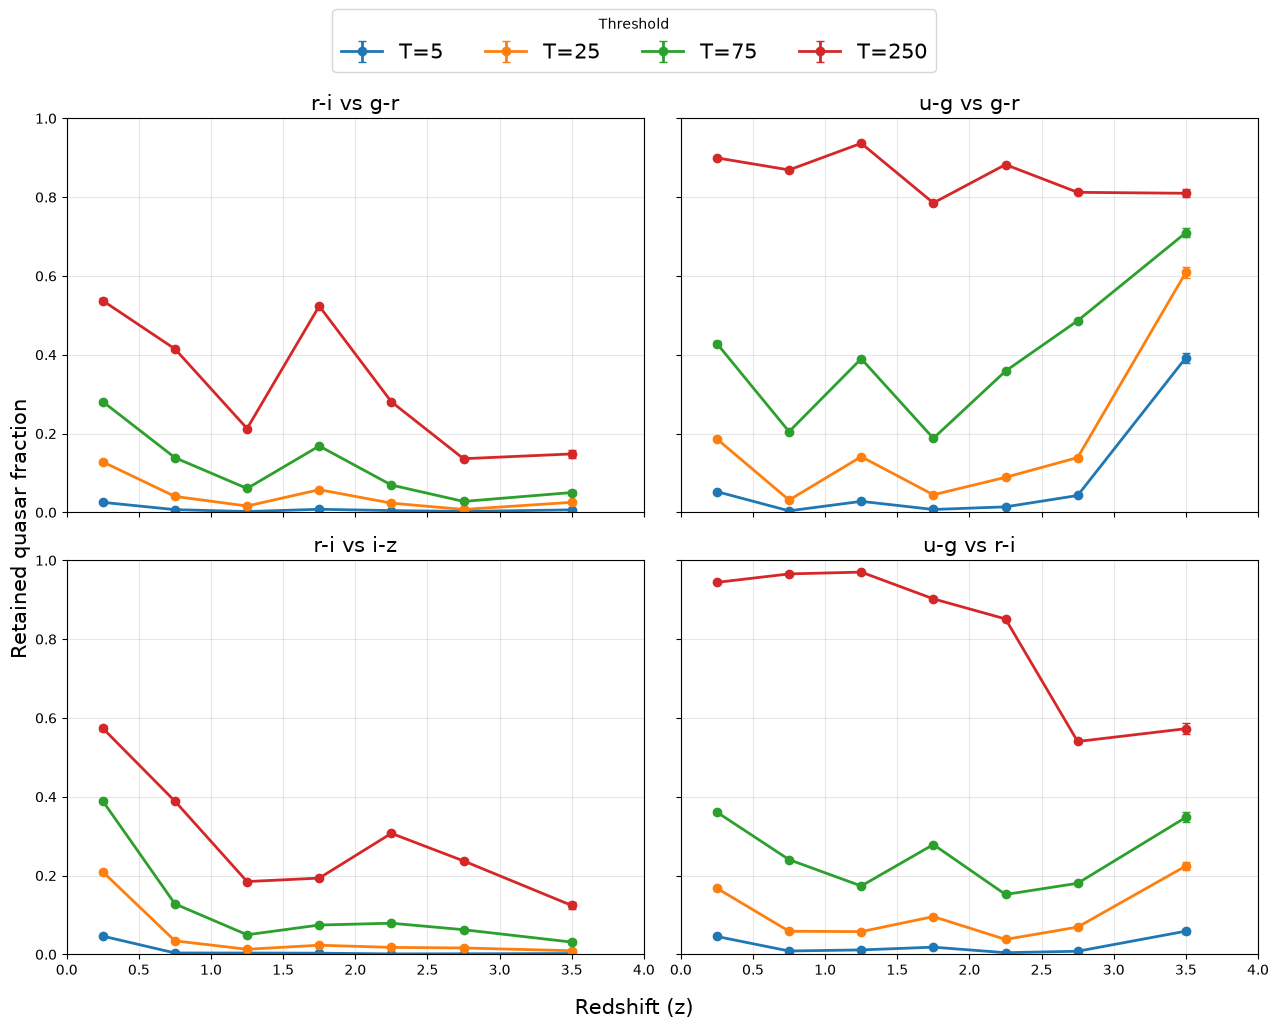

,projection,threshold,n_grid,redshift_bin,z_mid,N,N_retained,retained_fraction,sigma_binomial
0,r-i vs g-r,5,200,0-0.5,0.25,7332,187,0.025505,0.001841
1,r-i vs g-r,5,200,0.5-1.0,0.75,31255,218,0.006975,0.000471
2,r-i vs g-r,5,200,1.0-1.5,1.25,32773,72,0.002197,0.000259
3,r-i vs g-r,5,200,1.5-2.0,1.75,35690,281,0.007873,0.000468
4,r-i vs g-r,5,200,2.0-2.5,2.25,39766,183,0.004602,0.000339
...,...,...,...,...,...,...,...,...,...
107,u-g vs r-i,250,200,1.0-1.5,1.25,32773,31794,0.970128,0.000940
108,u-g vs r-i,250,200,1.5-2.0,1.75,35690,32202,0.902270,0.001572
109,u-g vs r-i,250,200,2.0-2.5,2.25,39766,33853,0.851305,0.001784
110,u-g vs r-i,250,200,2.5-3.0,2.75,14631,7905,0.540291,0.004120


In [6]:
z_bins = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0])
z_labels = ['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '3.0-4.0']
z_mid = (z_bins[:-1] + z_bins[1:]) / 2

n_grid_final = 200
thresholds = [5, 25, 75, 250]
x_range, y_range = (-2, 4), (-2, 4)

projections = [
    (r_i_clean_star, g_r_clean_star, r_i_clean_qso, g_r_clean_qso, 'r-i', 'g-r'),
    (u_g_clean_star, g_r_clean_star, u_g_clean_qso, g_r_clean_qso, 'u-g', 'g-r'),
    (r_i_clean_star, i_z_clean_star, r_i_clean_qso, i_z_clean_qso, 'r-i', 'i-z'),
    (u_g_clean_star, r_i_clean_star, u_g_clean_qso, r_i_clean_qso, 'u-g', 'r-i'),
]

retention_final_results = []

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (sx, sy, qx, qy, xlab, ylab) in zip(axes, projections):

    H_star, xedges, yedges = np.histogram2d(sx, sy, bins=n_grid_final, range=[x_range, y_range])

    xbin = np.searchsorted(xedges, qx, side='right') - 1
    ybin = np.searchsorted(yedges, qy, side='right') - 1

    inside = (
        np.isfinite(qx) & np.isfinite(qy) &
        (qx >= xedges[0]) & (qx <= xedges[-1]) &
        (qy >= yedges[0]) & (qy <= yedges[-1])
    )

    xbin = np.clip(xbin, 0, n_grid_final - 1)
    ybin = np.clip(ybin, 0, n_grid_final - 1)

    stellar_density = np.zeros(len(qx), dtype=float)
    stellar_density[inside] = H_star[xbin[inside], ybin[inside]]

    for threshold in thresholds:
        outside_locus = (~inside) | (stellar_density < threshold)

        fractions = []
        uncertainties = []

        for i, (low, high) in enumerate(zip(z_bins[:-1], z_bins[1:])):
    
            if i == 0:
                z_mask = (Z >= low) & (Z <= high)
            else:
                z_mask = (Z > low) & (Z <= high)

            n_bin = np.count_nonzero(z_mask)
            n_retained_bin = np.count_nonzero(outside_locus & z_mask)

            frac = n_retained_bin / n_bin if n_bin > 0 else np.nan
            fractions.append(frac)

            sigma = np.sqrt(frac * (1 - frac) / n_bin) if n_bin > 0 else np.nan
            uncertainties.append(sigma)

            retention_final_results.append({
                'projection': f'{xlab} vs {ylab}',
                'threshold': threshold,
                'n_grid': n_grid_final,
                'redshift_bin': z_labels[i],
                'z_mid': z_mid[i],
                'N': n_bin,
                'N_retained': n_retained_bin,
                'retained_fraction': frac,
                'sigma_binomial': sigma
            })

        ax.errorbar(z_mid, fractions, yerr=uncertainties, marker='o', linewidth=2,
                     capsize=3, label=f'T={threshold}')

    ax.set_title(f'{xlab} vs {ylab}', fontsize=15)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 4)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, title='Threshold', loc='upper center',
           bbox_to_anchor=(0.5, 1.03), ncol=4, fontsize=15)
fig.supxlabel('Redshift (z)', fontsize=15)
fig.supylabel('Retained quasar fraction', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

retention_final_df = pd.DataFrame(retention_final_results)
output_path = os.path.join(os.getcwd(), '..', 'Outputs', 'Retention_Fractions_Final.csv')
retention_final_df.to_csv(output_path, index=False)
retention_final_df